=== 3D Reconstruction Results ===
Point   Real Z      Reconstructed Z
------------------------------------
P1      5.00        5.00
P2      4.00        4.00
P3      6.00        6.00
P4      3.50        3.50
P5      4.50        4.50


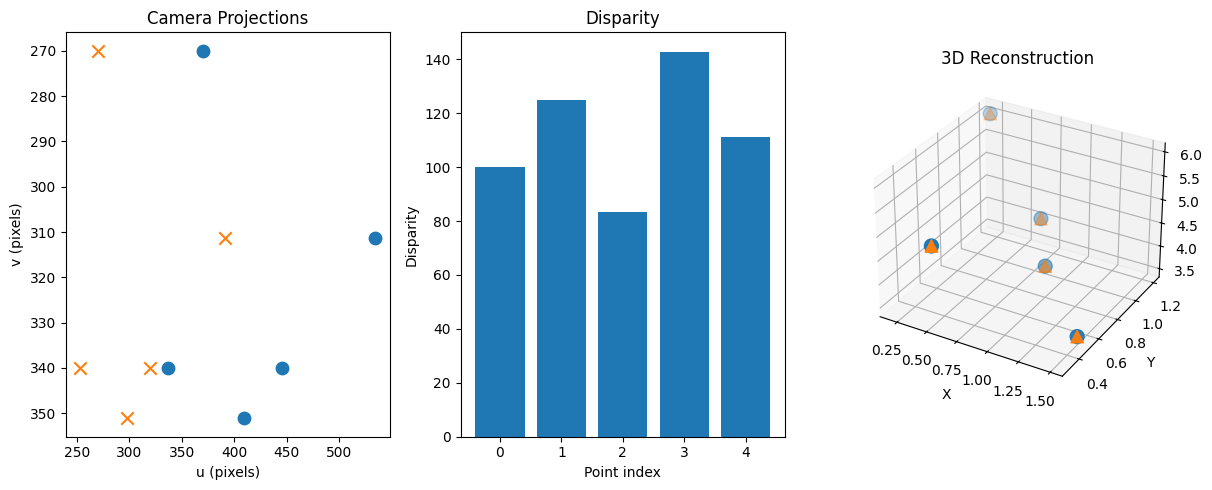


Plot saved as 3d_reconstruction.png


In [1]:
# =========================================
# 1. Install Required Libraries
# =========================================
!pip install matplotlib numpy -q

# =========================================
# 2. Import Libraries
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================================
# 3. Camera Parameters
# =========================================
baseline = 1.0        # distance between cameras
focal_length = 500    # focal length (pixels)
image_width = 640
image_height = 480

# =========================================
# 4. Define Real 3D Points
# =========================================
real_points = np.array([
    [0.5, 0.3, 5.0],
    [1.0, 0.8, 4.0],
    [0.2, 1.2, 6.0],
    [1.5, 0.5, 3.5],
    [0.8, 1.0, 4.5],
])

# =========================================
# 5. Projection Function
# =========================================
def project_to_image(points, cam_x=0):
    projected = []
    for p in points:
        x, y, z = p[0] - cam_x, p[1], p[2]

        u = focal_length * x / z + image_width / 2
        v = focal_length * y / z + image_height / 2

        projected.append((u, v))
    return np.array(projected)

# =========================================
# 6. Project Points to Left & Right Camera
# =========================================
left_proj  = project_to_image(real_points, cam_x=0)
right_proj = project_to_image(real_points, cam_x=baseline)

# =========================================
# 7. Compute Disparity
# =========================================
disparity = left_proj[:, 0] - right_proj[:, 0]

# Avoid division by zero
disparity[disparity == 0] = 0.1

# =========================================
# 8. Depth Calculation
# =========================================
depth_reconstructed = (focal_length * baseline) / disparity

# =========================================
# 9. Print Results
# =========================================
print("=== 3D Reconstruction Results ===")
print(f"{'Point':<8}{'Real Z':<12}{'Reconstructed Z'}")
print("-" * 36)

for i, (real, recon) in enumerate(zip(real_points[:, 2], depth_reconstructed)):
    print(f"P{i+1:<7}{real:<12.2f}{recon:.2f}")

# =========================================
# 10. Reconstruct X and Y
# =========================================
reconstructed_x = (left_proj[:, 0] - image_width/2) * depth_reconstructed / focal_length
reconstructed_y = (left_proj[:, 1] - image_height/2) * depth_reconstructed / focal_length

# =========================================
# 11. Visualization
# =========================================
fig = plt.figure(figsize=(12, 5))

# --- 2D Projections ---
ax1 = fig.add_subplot(131)
ax1.scatter(left_proj[:,0], left_proj[:,1], s=80)
ax1.scatter(right_proj[:,0], right_proj[:,1], marker='x', s=80)
ax1.set_title("Camera Projections")
ax1.set_xlabel("u (pixels)")
ax1.set_ylabel("v (pixels)")
ax1.invert_yaxis()

# --- Disparity ---
ax2 = fig.add_subplot(132)
ax2.bar(range(len(disparity)), disparity)
ax2.set_title("Disparity")
ax2.set_xlabel("Point index")
ax2.set_ylabel("Disparity")

# --- 3D Reconstruction ---
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(real_points[:,0], real_points[:,1], real_points[:,2], s=100)
ax3.scatter(reconstructed_x, reconstructed_y, depth_reconstructed, marker='^', s=80)
ax3.set_title("3D Reconstruction")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")

plt.tight_layout()
plt.savefig("3d_reconstruction.png", dpi=100)
plt.show()

print("\nPlot saved as 3d_reconstruction.png")